# 03 — Model Training & Selection

**流程**: 加载数据 → 时序划分 → 特征选择(仅训练集) → 全模型超参调优 → 测试集评估 → 收敛性检查 → 保存运行记录 → Ensemble Blending 验证

**核心功能**:
1. ✅ 特征选择仅在训练集上进行，避免数据泄露
2. ✅ 全部模型调优后，按 Test RMSE 排序评估
3. ✅ Ensemble Blending（ElasticNet + CatBoost）融合验证
4. ✅ 每次运行结果追加到 `outputs/run_history.csv`，重跑时可对比哪次 RMSE 最低

**输入**: `data/raw/train_data.csv`  
**输出**: `outputs/models/*.pkl`, `outputs/run_history.csv`, `outputs/figures/*.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR, RANDOM_STATE
from src.preprocessing import load_and_clean, build_feature_matrix
from src.feature_engineering import compute_ensemble_importance
from src.models import discover_models, save_model

RUN_HISTORY_PATH = MODEL_DIR.parent / "run_history.csv"
TOP_K = 3

# ── 每次运行前可修改此备注，记录本次改了什么 ──
RUN_NOTES = ""

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. 加载原始数据 & 时序划分

从原始数据重新开始，按时间排序后按 80/20 划分训练集和测试集。  
使用**时序划分**（前 80% 训练、后 20% 测试），确保不会用"未来数据"训练。

In [2]:
df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)

X_full, y_full, all_features = build_feature_matrix(df, TARGET)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")
print(f"Total features (before selection): {len(all_features)}")

split_idx = int(len(X_full) * 0.8)
X_train_raw, X_test_raw = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

print(f"\nTrain: {X_train_raw.shape}  (rows 0–{split_idx - 1})")
print(f"Test:  {X_test_raw.shape}  (rows {split_idx}–{len(X_full) - 1})")

/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['startdate'] = pd.to_datetime(df['startdate'])
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year']   = df['startdate'].dt.year
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/src/preprocessing.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once u

Full dataset: X=(375734, 242), y=(375734,)
Total features (before selection): 242

Train: (300587, 242)  (rows 0–300586)
Test:  (75147, 242)  (rows 300587–375733)


## 2. 特征选择（仅在训练集上）

使用 Lasso + ElasticNet + RandomForest 集成方法，**仅在训练集上**计算特征重要性。  
测试集完全不参与特征选择，杜绝数据泄露。

In [3]:
selected_score, full_score = compute_ensemble_importance(
    X_train_raw, y_train, top_n=30, use_cache=False
)
selected_features = selected_score.index.tolist()

print(f"\nSelected {len(selected_features)} features (train-only):")
print(selected_features)

X_train = X_train_raw[selected_features]
X_test = X_test_raw[selected_features]
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

  [1/3] Lasso …
  [2/3] ElasticNet …
  [3/3] RandomForest …
  Top-30 投票 ≥2/3: 25 个特征 (3/3=5, 2/3=20)
  Cached scores to /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/cache/

Selected 25 features (train-only):
['contest-slp-14d__slp', 'contest-wind-h500-14d__wind-hgt-500', 'nmme-tmp2m-34w__gfdlflorb', 'nmme-tmp2m-34w__cfsv2', 'nmme-tmp2m-56w__cfsv2', 'nmme-tmp2m-56w__gfdlflorb', 'contest-wind-h850-14d__wind-hgt-850', 'nmme-tmp2m-56w__nasa', 'nmme-tmp2m-56w__gfdlflora', 'nmme-tmp2m-34w__nasa', 'elevation__elevation', 'nmme-tmp2m-34w__gfdlflora', 'contest-wind-h100-14d__wind-hgt-100', 'lon', 'contest-pres-sfc-gauss-14d__pres', 'contest-rhum-sig995-14d__rhum', 'contest-wind-vwnd-925-14d__wind-vwnd-925', 'wind-vwnd-925-2010-8', 'wind-hgt-10-2010-9', 'contest-wind-uwnd-925-14d__wind-uwnd-925', 'icec-2010-8', 'wind-hgt-10-2010-7', 'sst-2010-5', 'wind-uwnd-250-2010-10', 'wind-uwnd-250-2010-18']

X_train: (300587, 25), X_test: (75147, 25)


## 3. 超参数调优（所有模型）

对所有模型做 `RandomizedSearchCV`，使用 `TimeSeriesSplit` 作为交叉验证策略。  
**优化策略**：用训练集最近 30% 的数据做调参（时序上最接近测试集，更有代表性），3 折 CV，找到最优参数后再用全量训练集训练。

In [4]:
import time as _time
_run_start = _time.time()

registry = discover_models()
print(f"Discovered {len(registry)} models: {list(registry.keys())}")

TUNE_FRAC = 0.2
N_ITER = 20

tune_size = int(len(X_train) * TUNE_FRAC)
X_tune = X_train.iloc[-tune_size:]
y_tune = y_train.iloc[-tune_size:]
print(f"Tuning subset: {X_tune.shape} (last {TUNE_FRAC:.0%} of train)\n")

tscv_tune = TimeSeriesSplit(n_splits=3)
tuned_pipelines = {}
tuning_info = {}

for name, entry in registry.items():
    grid = entry.param_grid()
    if not grid:
        print(f"[{name}] No param_grid, keeping default.\n")
        tuned_pipelines[name] = entry.build_pipeline()
        tuning_info[name] = {"cv_rmse": None, "best_params": {}}
        continue

    print(f"[{name}] Tuning ({len(grid)} param groups, n_iter={N_ITER})...")
    search = RandomizedSearchCV(
        entry.build_pipeline(), grid,
        n_iter=N_ITER, cv=tscv_tune,
        scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
    )
    search.fit(X_tune, y_tune)
    cv_rmse = np.sqrt(-search.best_score_)
    print(f"  CV RMSE: {cv_rmse:.4f}")
    print(f"  Params:  {search.best_params_}\n")
    tuned_pipelines[name] = search.best_estimator_
    tuning_info[name] = {
        "cv_rmse": round(cv_rmse, 4),
        "best_params": search.best_params_,
    }

print(f"Done. Tuned {len(tuned_pipelines)} models.")

Discovered 6 models: ['catboost', 'elasticnet', 'lasso', 'lightgbm', 'random_forest', 'xgboost']
Tuning subset: (60117, 25) (last 20% of train)

[catboost] Tuning (5 param groups, n_iter=20)...
  CV RMSE: 2.1131
  Params:  {'model__subsample': 1.0, 'model__random_strength': 1, 'model__learning_rate': 0.05, 'model__l2_leaf_reg': 1, 'model__depth': 5}

[elasticnet] Tuning (2 param groups, n_iter=20)...
  CV RMSE: 1.9639
  Params:  {'model__l1_ratio': 0.7, 'model__alpha': 0.02}

[lasso] Tuning (1 param groups, n_iter=20)...


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  CV RMSE: 1.9813
  Params:  {'model__alpha': 0.01}

[lightgbm] Tuning (7 param groups, n_iter=20)...


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiay

  CV RMSE: 2.1988
  Params:  {'model__subsample': 0.7, 'model__reg_lambda': 0, 'model__reg_alpha': 0.1, 'model__num_leaves': 7, 'model__n_estimators': 1200, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

[random_forest] Tuning (4 param groups, n_iter=20)...


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV RMSE: 2.6443
  Params:  {'model__n_estimators': 300, 'model__min_samples_leaf': 3, 'model__max_features': 0.5, 'model__max_depth': None}

[xgboost] Tuning (7 param groups, n_iter=20)...
  CV RMSE: 2.1451
  Params:  {'model__subsample': 0.7, 'model__reg_lambda': 5, 'model__n_estimators': 1500, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Done. Tuned 6 models.


## 4. 测试集评估 → 选出 Top 3

用调参后的最优参数在**全量训练集**上训练，然后在 **20% 测试集**上评估。  
按 Test RMSE 排序，自动选出表现最好的 **Top 3** 模型。

In [5]:
test_rows = []
predictions = {}

for name, pipe in tuned_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    test_rows.append({
        'Model': name,
        'Test RMSE': round(rmse, 4),
        'Test R²': round(r2, 4),
    })
    predictions[name] = y_pred
    print(f"[{name}] RMSE={rmse:.4f}, R²={r2:.4f}")

all_results = pd.DataFrame(test_rows).set_index('Model').sort_values('Test RMSE')

top3_names = all_results.head(TOP_K).index.tolist()
print(f"\n{'='*55}")
print(f"  ★ Top {TOP_K} models: {top3_names}")
print(f"{'='*55}")
all_results

[catboost] RMSE=1.9528, R²=0.9056
[elasticnet] RMSE=1.8761, R²=0.9129
[lasso] RMSE=1.8935, R²=0.9113


/Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[lightgbm] RMSE=1.9255, R²=0.9082
[random_forest] RMSE=1.8580, R²=0.9146
[xgboost] RMSE=1.8523, R²=0.9151

  ★ Top 3 models: ['xgboost', 'random_forest', 'elasticnet']


,Test RMSE,Test R²
Model,,
xgboost,1.8523,0.9151
random_forest,1.8580,0.9146
elasticnet,1.8761,0.9129
lasso,1.8935,0.9113
lightgbm,1.9255,0.9082
catboost,1.9528,0.9056


## 5. 收敛性检查

对**所有梯度提升模型**（CatBoost / XGBoost / LightGBM），用验证集重新训练并画 **训练 vs 验证 RMSE 曲线**。  
- 曲线末端趋于平坦 → 已收敛  
- 曲线末端仍在明显下降 → 可尝试增大 `iterations` / `n_estimators`  
- 验证曲线反而上升 → 过拟合，需降低复杂度

线性模型（Lasso / ElasticNet）和 RandomForest 不需要这种检查。

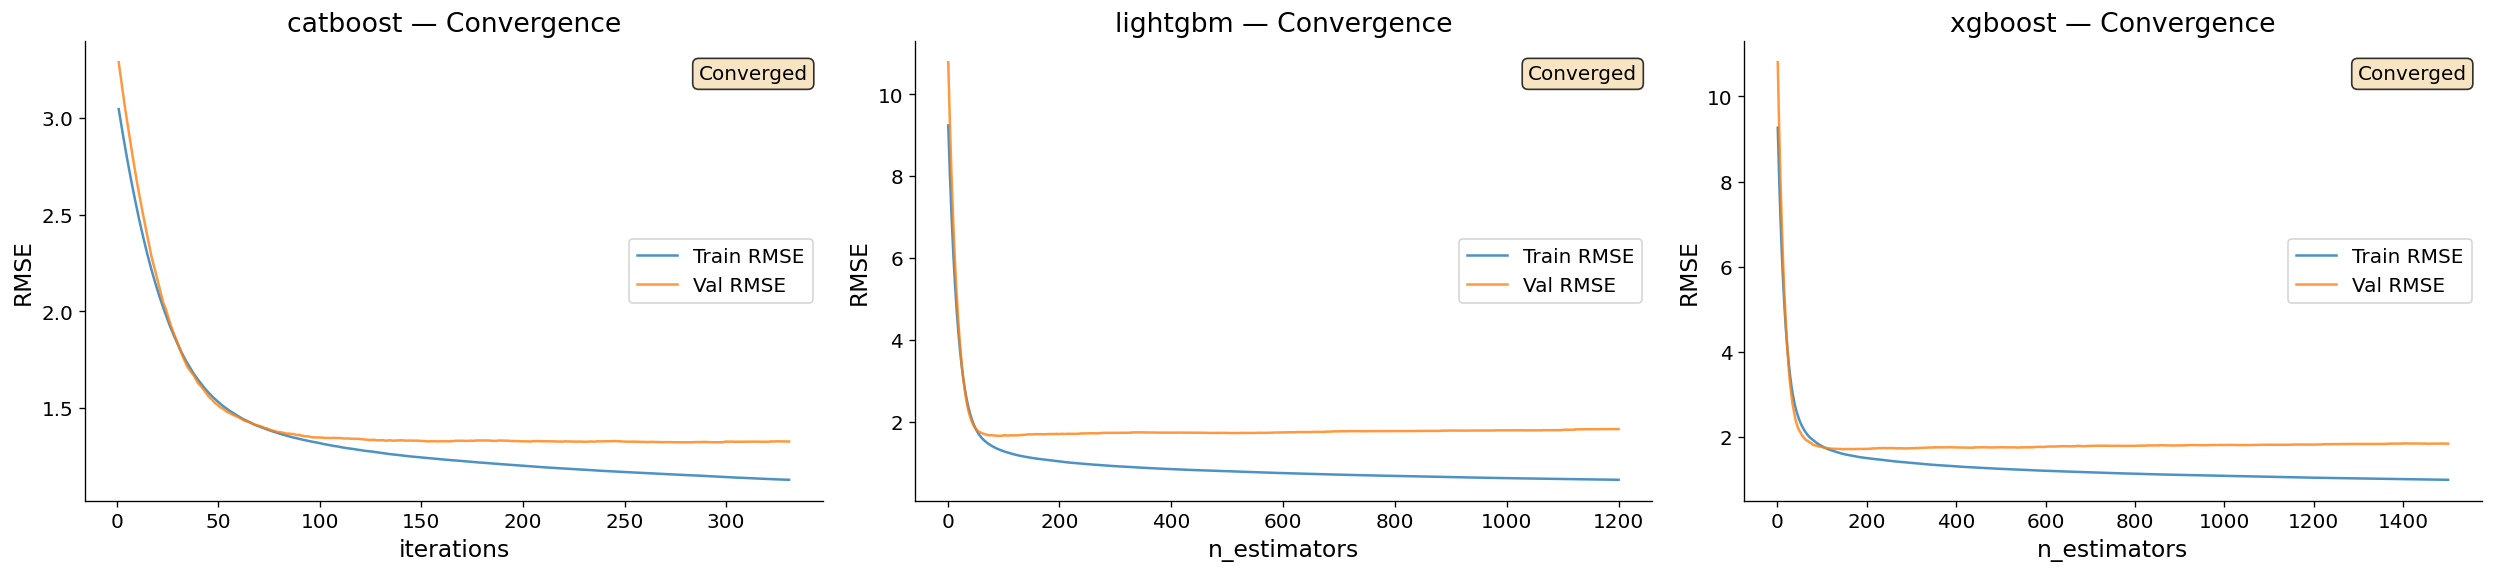

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/convergence_check.png


In [6]:
from sklearn.preprocessing import StandardScaler

boosting_models = {
    'catboost':  'iterations',
    'xgboost':   'n_estimators',
    'lightgbm':  'n_estimators',
}

all_boosting = [n for n in tuned_pipelines if n in boosting_models]

if not all_boosting:
    print("没有梯度提升模型，跳过收敛检查。")
else:
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    fig, axes = plt.subplots(1, len(all_boosting),
                             figsize=(7 * len(all_boosting), 5))
    if len(all_boosting) == 1:
        axes = [axes]

    for ax, name in zip(axes, all_boosting):
        pipe = tuned_pipelines[name]
        best_params = tuning_info[name]['best_params']
        inner_model = pipe.named_steps['model']
        params = inner_model.get_params()

        if name == 'catboost':
            from catboost import CatBoostRegressor
            n_rounds = params.get('iterations', 500)
            model = CatBoostRegressor(
                **{k.replace('model__', ''): v for k, v in best_params.items()
                   if k.startswith('model__')},
                iterations=n_rounds, verbose=0, random_seed=42,
                eval_metric='RMSE',
            )
            # use remaining params from tuned model
            model.set_params(**{k: v for k, v in params.items()
                                if k not in ('iterations', 'verbose', 'random_seed',
                                             'eval_metric')
                                and not k.startswith('_')})
            model.fit(X_tr_sc, y_train,
                      eval_set=(X_te_sc, y_test), verbose=0)
            train_rmse = [x ** 0.5 if x > 0 else x
                          for x in model.evals_result_['learn']['RMSE']]
            val_rmse = [x ** 0.5 if x > 0 else x
                        for x in model.evals_result_['validation']['RMSE']]

        elif name == 'xgboost':
            from xgboost import XGBRegressor
            n_rounds = params.get('n_estimators', 500)
            model = XGBRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbosity=0,
                eval_metric='rmse',
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      verbose=False)
            res = model.evals_result()
            train_rmse = res['validation_0']['rmse']
            val_rmse = res['validation_1']['rmse']

        elif name == 'lightgbm':
            from lightgbm import LGBMRegressor
            n_rounds = params.get('n_estimators', 500)
            model = LGBMRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbose=-1,
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      eval_metric='rmse')
            train_rmse = [x[1] for x in model.evals_result_['training']['rmse']] \
                if isinstance(model.evals_result_['training']['rmse'][0], tuple) \
                else model.evals_result_['training']['rmse']
            val_rmse = model.evals_result_['valid_1']['rmse']

        iters = range(1, len(train_rmse) + 1)
        ax.plot(iters, train_rmse, label='Train RMSE', linewidth=1.5, alpha=0.8)
        ax.plot(iters, val_rmse, label='Val RMSE', linewidth=1.5, alpha=0.8)
        ax.set_xlabel(boosting_models[name])
        ax.set_ylabel('RMSE')
        ax.set_title(f'{name} — Convergence')
        ax.legend()

        last_5_val = val_rmse[-5:]
        delta = last_5_val[0] - last_5_val[-1]
        if delta < 0.001:
            verdict = "Converged"
        elif delta < 0.01:
            verdict = "Near converged"
        else:
            verdict = "Not converged"
        ax.text(0.98, 0.95, verdict, transform=ax.transAxes,
                ha='right', va='top', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'convergence_check.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'convergence_check.png'}")

## 6. 保存模型 & 运行记录

- Top 3 模型保存到 `outputs/models/<run_id>/` 子目录，**不会覆盖**历史运行
- 本次运行的**所有模型**结果追加到 `outputs/run_history.csv`
- 恢复某次历史模型: `load_model("catboost", run_id="20260310_231542")`

In [8]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ── 保存 Top 3 模型到 run_id 子目录 ──
for name in top3_names:
    save_model(tuned_pipelines[name], name, run_id=run_id)
print(f"Saved top 3 models → {MODEL_DIR / run_id}/")

run_dir = MODEL_DIR / run_id
features_path = run_dir / "selected_features.json"
with open(features_path, 'w') as f:
    json.dump(selected_features, f, indent=2)
print(f"Saved features → {features_path}")

# ── 构建运行记录 ──
history_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    history_rows.append({
        'run_id': run_id,
        'timestamp': run_ts,
        'model': name,
        'best_params': json.dumps(info.get('best_params', {})),
        'cv_rmse': info.get('cv_rmse', None),
        'test_rmse': all_results.loc[name, 'Test RMSE'],
        'test_r2': all_results.loc[name, 'Test R²'],
        'n_features': len(selected_features),
        'is_top3': name in top3_names,
        'notes': RUN_NOTES,
    })

new_rows = pd.DataFrame(history_rows)
if RUN_HISTORY_PATH.exists():
    history = pd.concat([pd.read_csv(RUN_HISTORY_PATH), new_rows], ignore_index=True)
else:
    history = new_rows
history.to_csv(RUN_HISTORY_PATH, index=False)

print(f"\n{'='*55}")
print(f"  Run [{run_id}] saved to {RUN_HISTORY_PATH}")
print(f"  Total runs in history: {history['run_id'].nunique()}")
print(f"{'='*55}")

Saved top 3 models → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/models/20260315_182014/
Saved features → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/models/20260315_182014/selected_features.json

  Run [20260315_182014] saved to /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/run_history.csv
  Total runs in history: 3


## 7. 历史运行对比

加载所有历史运行记录，表格展示每次 run 的最佳模型，多次运行时还会画 RMSE 变化趋势图。  
**使用方式**: 修改参数后重跑整个 notebook，这里会自动对比所有历史结果。

Total runs in history: 2

Best model per run (sorted by Test RMSE):


,run_id,timestamp,model,cv_rmse,test_rmse,test_r2,n_features,notes
0,20260315_135335,2026-03-15 13:53:35,xgboost,2.2771,1.8450,0.9157,25,NaN
1,20260315_182014,2026-03-15 18:20:14,xgboost,2.1451,1.8523,0.9151,25,NaN



★ Historical best: run [20260315_135335] model=xgboost, Test RMSE=1.845


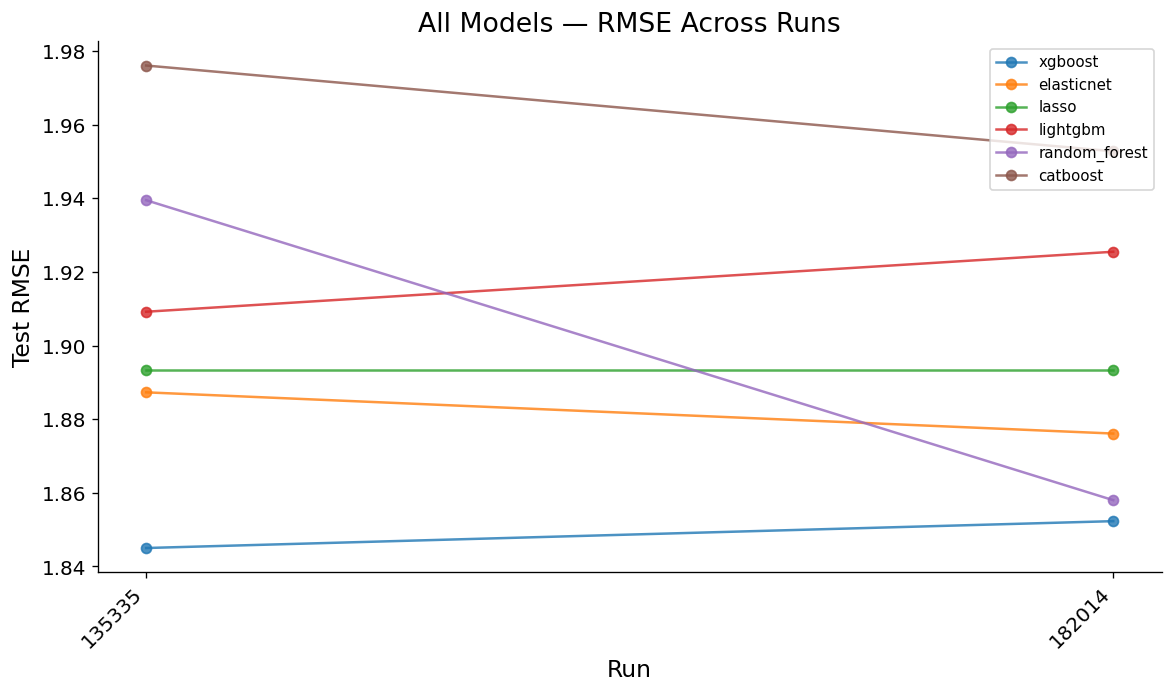

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/rmse_history.png


In [10]:
history = pd.read_csv(RUN_HISTORY_PATH)
n_runs = history['run_id'].nunique()
print(f"Total runs in history: {n_runs}\n")

# ── 每次 run 的最佳模型 ──
best_per_run = history.loc[history.groupby('run_id')['test_rmse'].idxmin()]
best_per_run = best_per_run[[
    'run_id', 'timestamp', 'model', 'cv_rmse',
    'test_rmse', 'test_r2', 'n_features', 'notes',
]].sort_values('test_rmse')

print("Best model per run (sorted by Test RMSE):")
display(best_per_run.reset_index(drop=True))

global_best = best_per_run.iloc[0]
print(f"\n★ Historical best: run [{global_best['run_id']}] "
      f"model={global_best['model']}, "
      f"Test RMSE={global_best['test_rmse']}")

# ── 多次运行时画趋势图 ──
if n_runs > 1:
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name in history['model'].unique():
        md = history[history['model'] == model_name].sort_values('run_id')
        ax.plot(range(len(md)), md['test_rmse'].values,
                'o-', label=model_name, markersize=6, alpha=0.8)
    ax.set_xticks(range(n_runs))
    ax.set_xticklabels([rid[-6:] for rid in history['run_id'].unique()],
                       rotation=45, ha='right')
    ax.set_xlabel('Run')
    ax.set_ylabel('Test RMSE')
    ax.set_title('All Models — RMSE Across Runs')
    ax.legend(fontsize=9, loc='upper right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'rmse_history.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'rmse_history.png'}")
else:
    print("\nOnly 1 run so far. Re-run with different params to see comparison charts.")

## 8. 当前 Run 详细参数记录

展示本次运行中所有模型的调优参数，方便回溯。

In [11]:
print(f"Run ID: {run_id}")
print(f"Notes:  {RUN_NOTES or '(none)'}")
print(f"Features: {len(selected_features)}")
print(f"Top {TOP_K}: {top3_names}\n")

param_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    param_rows.append({
        'Model': name,
        'CV RMSE': info.get('cv_rmse', '-'),
        'Test RMSE': all_results.loc[name, 'Test RMSE'],
        'Test R²': all_results.loc[name, 'Test R²'],
        'Top3': '★' if name in top3_names else '',
        'Best Params': json.dumps(info.get('best_params', {}), indent=None),
    })
display(pd.DataFrame(param_rows).set_index('Model'))

Run ID: 20260315_182014
Notes:  (none)
Features: 25
Top 3: ['xgboost', 'random_forest', 'elasticnet']



,CV RMSE,Test RMSE,Test R²,Top3,Best Params
Model,,,,,
xgboost,2.1451,1.8523,0.9151,★,"{""model__subsample"": 0.7, ""model__reg_lambda"":..."
random_forest,2.6443,1.8580,0.9146,★,"{""model__n_estimators"": 300, ""model__min_sampl..."
elasticnet,1.9639,1.8761,0.9129,★,"{""model__l1_ratio"": 0.7, ""model__alpha"": 0.02}"
lasso,1.9813,1.8935,0.9113,,"{""model__alpha"": 0.01}"
lightgbm,2.1988,1.9255,0.9082,,"{""model__subsample"": 0.7, ""model__reg_lambda"":..."
catboost,2.1131,1.9528,0.9056,,"{""model__subsample"": 1.0, ""model__random_stren..."


## 9. Ensemble: Best-Linear + Best-Tree (Auto-Select)

自动从 Top 模型中选取**最佳线性模型**和**最佳树模型**，通过以下两种策略融合：

1. **Weight Search** — 暴力搜索最优 blending 权重 `y = w × linear + (1−w) × tree`
2. **OOF Stacking** — 用 TimeSeriesSplit 生成 out-of-fold 预测，训练带截距的 LinearRegression 作为 meta-learner，自动学习最优权重与偏差校正

融合的核心价值在于**多样性**：线性模型捕获全局线性趋势，树模型补充非线性交互。

Best linear: elasticnet (RMSE=1.8761)
Best tree:   xgboost (RMSE=1.8523)

[Weight Search] w(elasticnet)=0.50, w(xgboost)=0.50
  RMSE = 1.6837,  R² = 0.9298

[OOF Stacking] coef=[0.7629 0.1913], intercept=0.6576
  RMSE = 1.6822,  R² = 0.9300,  Bias = -0.3502

  Winner: Stacking  RMSE=1.6822


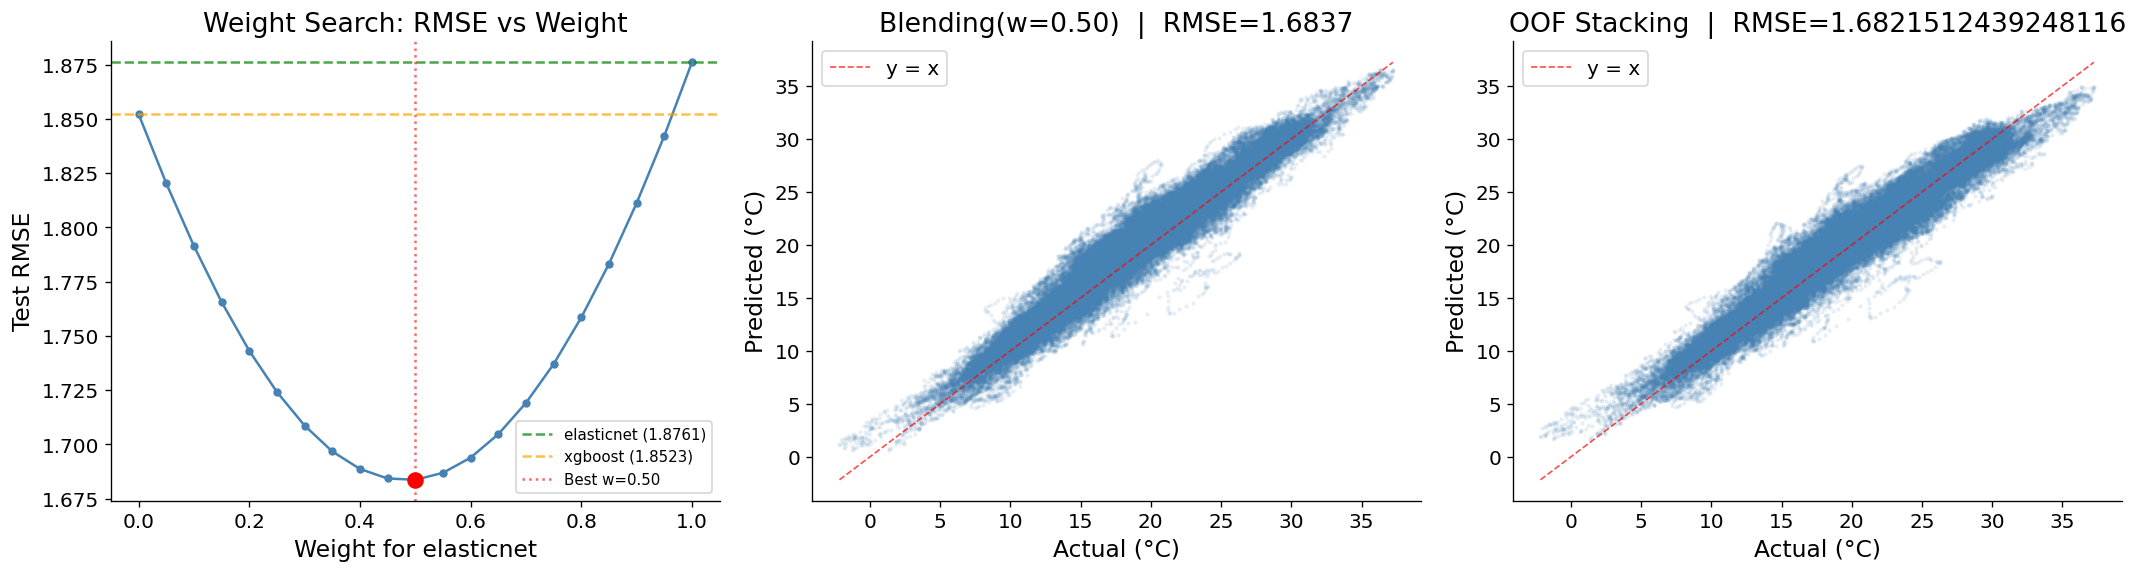

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/ensemble_blending.png


In [12]:
from sklearn.linear_model import LinearRegression

LINEAR_MODELS = {'lasso', 'elasticnet', 'ridge'}
TREE_MODELS   = {'xgboost', 'lightgbm', 'catboost', 'random_forest'}

ranked = all_results.index.tolist()
best_linear = next((n for n in ranked if n in LINEAR_MODELS), None)
best_tree   = next((n for n in ranked if n in TREE_MODELS), None)
assert best_linear and best_tree, "Need at least one linear and one tree model"

linear_pred = predictions[best_linear]
tree_pred   = predictions[best_tree]
linear_rmse = all_results.loc[best_linear, 'Test RMSE']
tree_rmse   = all_results.loc[best_tree, 'Test RMSE']

print(f"Best linear: {best_linear} (RMSE={linear_rmse})")
print(f"Best tree:   {best_tree} (RMSE={tree_rmse})")

# ── Strategy 1: Weight Search ──
weights = np.arange(0.0, 1.05, 0.05)
blend_rows = []
for w in weights:
    blended = w * linear_pred + (1 - w) * tree_pred
    rmse = np.sqrt(mean_squared_error(y_test, blended))
    r2 = r2_score(y_test, blended)
    blend_rows.append({'w_linear': round(w, 2), 'RMSE': round(rmse, 4), 'R²': round(r2, 4)})

blend_df = pd.DataFrame(blend_rows)
best_idx = blend_df['RMSE'].idxmin()
best_w = blend_df.loc[best_idx, 'w_linear']
best_rmse = blend_df.loc[best_idx, 'RMSE']
best_r2 = blend_df.loc[best_idx, 'R²']
blended_best = best_w * linear_pred + (1 - best_w) * tree_pred

print(f"\n[Weight Search] w({best_linear})={best_w:.2f}, w({best_tree})={1-best_w:.2f}")
print(f"  RMSE = {best_rmse:.4f},  R² = {best_r2:.4f}")

# ── Strategy 2: OOF Stacking ──
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=5)
oof_linear = np.full(len(y_train), np.nan)
oof_tree   = np.full(len(y_train), np.nan)

for train_idx, val_idx in tscv.split(X_train):
    pl = clone(tuned_pipelines[best_linear])
    pl.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_linear[val_idx] = pl.predict(X_train.iloc[val_idx])

    pt = clone(tuned_pipelines[best_tree])
    pt.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_tree[val_idx] = pt.predict(X_train.iloc[val_idx])

valid = ~np.isnan(oof_linear)
meta_X_train = np.column_stack([oof_linear[valid], oof_tree[valid]])
meta_X_test  = np.column_stack([linear_pred, tree_pred])

meta_model = LinearRegression()
meta_model.fit(meta_X_train, y_train.values[valid])
stacked_pred = meta_model.predict(meta_X_test)
stack_rmse = np.sqrt(mean_squared_error(y_test, stacked_pred))
stack_r2 = r2_score(y_test, stacked_pred)
stack_bias = np.mean(y_test.values - stacked_pred)

print(f"\n[OOF Stacking] coef={np.round(meta_model.coef_, 4)}, intercept={meta_model.intercept_:.4f}")
print(f"  RMSE = {stack_rmse:.4f},  R² = {stack_r2:.4f},  Bias = {stack_bias:.4f}")

# ── Pick best strategy ──
if stack_rmse <= best_rmse:
    ensemble_name = "Stacking"
    ensemble_pred = stacked_pred
    ensemble_rmse, ensemble_r2 = stack_rmse, stack_r2
else:
    ensemble_name = f"Blending(w={best_w:.2f})"
    ensemble_pred = blended_best
    ensemble_rmse, ensemble_r2 = best_rmse, best_r2

print(f"\n{'='*55}")
print(f"  Winner: {ensemble_name}  RMSE={ensemble_rmse:.4f}")
print(f"{'='*55}")

# ── Visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(blend_df['w_linear'], blend_df['RMSE'], 'o-', ms=4, color='steelblue')
ax.axhline(linear_rmse, ls='--', color='green', alpha=0.7, label=f'{best_linear} ({linear_rmse})')
ax.axhline(tree_rmse,   ls='--', color='orange', alpha=0.7, label=f'{best_tree} ({tree_rmse})')
ax.axvline(best_w, ls=':', color='red', alpha=0.6, label=f'Best w={best_w:.2f}')
ax.scatter([best_w], [best_rmse], color='red', s=80, zorder=5)
ax.set_xlabel(f'Weight for {best_linear}')
ax.set_ylabel('Test RMSE')
ax.set_title('Weight Search: RMSE vs Weight')
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(y_test, blended_best, alpha=0.08, s=3, color='steelblue')
lims = [min(y_test.min(), blended_best.min()), max(y_test.max(), blended_best.max())]
ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
ax.set_xlabel('Actual (°C)')
ax.set_ylabel('Predicted (°C)')
ax.set_title(f'Blending(w={best_w:.2f})  |  RMSE={best_rmse}')
ax.legend(loc='upper left')

ax = axes[2]
ax.scatter(y_test, stacked_pred, alpha=0.08, s=3, color='steelblue')
lims = [min(y_test.min(), stacked_pred.min()), max(y_test.max(), stacked_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
ax.set_xlabel('Actual (°C)')
ax.set_ylabel('Predicted (°C)')
ax.set_title(f'OOF Stacking  |  RMSE={stack_rmse}')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / 'ensemble_blending.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'ensemble_blending.png'}")

## 10. Ensemble Validation

对最佳线性模型、最佳树模型和获胜 Ensemble 分别做 **预测 vs 实际散点图** 和 **残差分布图**，
直观对比基模型与融合后的偏差模式和残差分布。

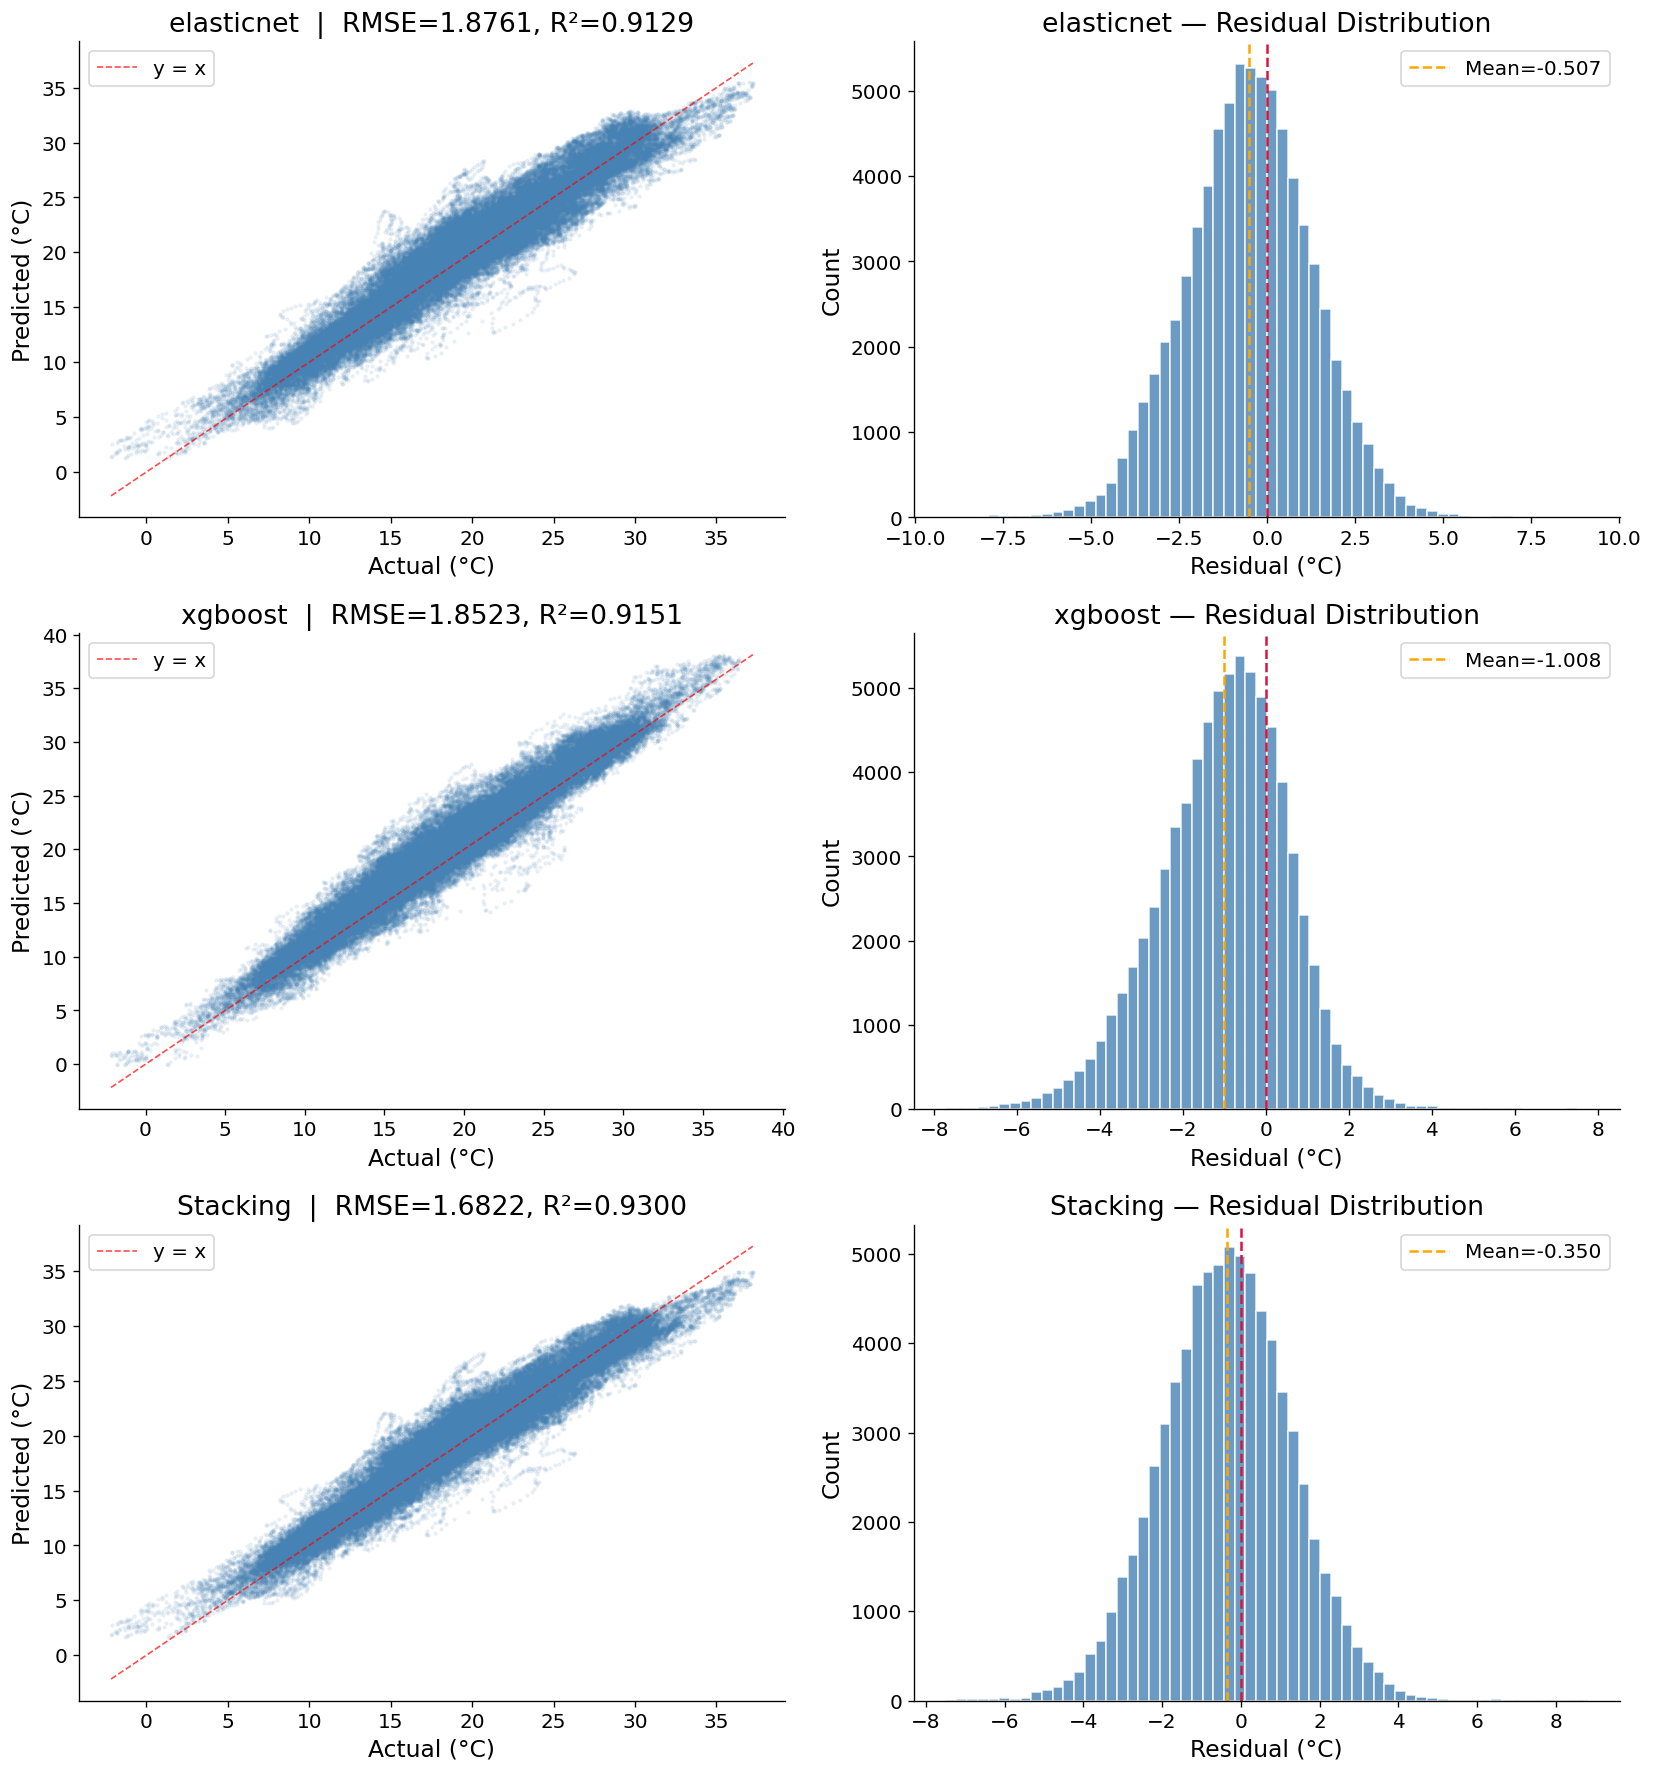

Saved → /Users/zhangjiayu/PycharmProjects/DS_Project/weather-forecast/outputs/figures/ensemble_validation.png

  Ensemble (Stacking):  RMSE=1.6822,  R²=0.9300
  Total runtime: 210.7 min (12642 s)


In [13]:
val_models = {
    best_linear: linear_pred,
    best_tree: tree_pred,
    ensemble_name: ensemble_pred,
}

n_models = len(val_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

for i, (label, y_pred) in enumerate(val_models.items()):
    residuals = y_test.values - y_pred
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_val = r2_score(y_test, y_pred)

    ax = axes[i, 0]
    ax.scatter(y_test, y_pred, alpha=0.08, s=3, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='y = x')
    ax.set_xlabel('Actual (°C)')
    ax.set_ylabel('Predicted (°C)')
    ax.set_title(f'{label}  |  RMSE={rmse_val:.4f}, R²={r2_val:.4f}')
    ax.legend(loc='upper left')

    ax = axes[i, 1]
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='orange', linestyle='--',
               label=f'Mean={residuals.mean():.3f}')
    ax.set_xlabel('Residual (°C)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} — Residual Distribution')
    ax.legend()

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / 'ensemble_validation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved → {FIG_DIR / 'ensemble_validation.png'}")

_elapsed = _time.time() - _run_start
print(f"\n{'='*55}")
print(f"  Ensemble ({ensemble_name}):  RMSE={ensemble_rmse:.4f},  R²={ensemble_r2:.4f}")
print(f"  Total runtime: {_elapsed/60:.1f} min ({_elapsed:.0f} s)")
print(f"{'='*55}")